In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3

import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
train_dir = "../dataset/seg_train/seg_train"
test_dir = "../dataset/seg_test/seg_test"

print(train_dir)
print(test_dir)

../dataset/seg_train/seg_train
../dataset/seg_test/seg_test


In [9]:
train_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = (299,299),
    batch_size = 32,
    shuffle = True,
    subset = 'training',
    validation_split = 0.2,
    seed = 42
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [7]:
train_dataset.class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [11]:
validation_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = (299,299),
    subset = 'validation',
    shuffle = True,
    validation_split = 0.2,
    seed = 42,
    batch_size = 32
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [14]:
test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size = 32,
    shuffle = False,
    image_size = (299,299)
)

Found 3000 files belonging to 6 classes.


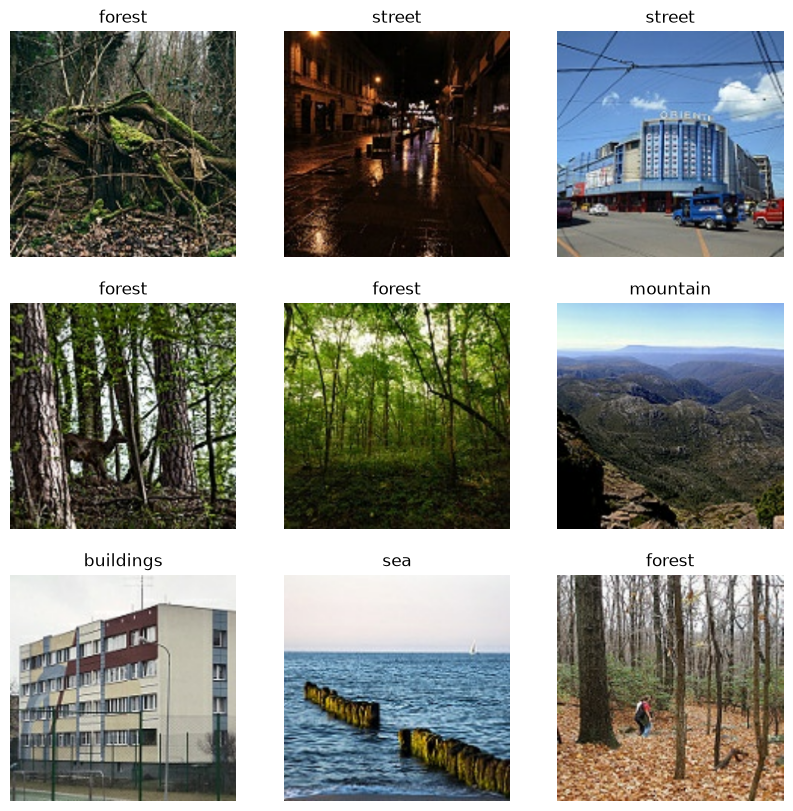

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_dataset.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [16]:
base_model = InceptionV3(
    weights = 'imagenet',
    include_top = False,
    input_shape = (299,299,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 42s 0us/step


In [17]:
base_model.trainable = False

In [19]:
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(6,activation = 'softmax')
])

In [20]:
from tensorflow.keras.applications.inception_v3 import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5


c:\Users\LENOVO\Desktop\InceptionV3_Transfer_Learning\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 1350s 4s/step - accuracy: 0.6865 - loss: 0.9532 - val_accuracy: 0.8735 - val_loss: 0.4902
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 1155s 3s/step - accuracy: 0.8665 - loss: 0.4341 - val_accuracy: 0.8942 - val_loss: 0.3458
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 10175s 29s/step - accuracy: 0.8856 - loss: 0.3418 - val_accuracy: 0.8999 - val_loss: 0.2994
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 3100s 9s/step - accuracy: 0.8941 - loss: 0.3034 - val_accuracy: 0.9038 - val_loss: 0.2754
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 3976s 11s/step - accuracy: 0.9006 - loss: 0.2803 - val_accuracy: 0.9063 - val_loss: 0.2616


In [23]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9080 - loss: 0.2616
Test Accuracy: 0.9079999923706055
Test Loss: 0.26159122586250305


In [24]:
images, labels = next(iter(test_dataset))

In [25]:
predictions = model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [26]:
predictions

array([[9.8318523e-01, 2.5836716e-04, 5.3108530e-04, 3.4817637e-04,
        4.4212579e-03, 1.1255995e-02],
       [9.2370892e-01, 2.8568932e-03, 1.6013267e-03, 2.7235735e-03,
        3.8392022e-03, 6.5270171e-02],
       [8.8548392e-01, 2.3616056e-03, 3.2395816e-03, 6.2650000e-03,
        4.4754073e-03, 9.8174468e-02],
       [9.7215009e-01, 3.0662681e-03, 1.4453429e-03, 9.8474172e-04,
        9.6467808e-03, 1.2706789e-02],
       [9.9466199e-01, 4.1752408e-04, 4.6177246e-04, 1.0762395e-03,
        1.0288950e-03, 2.3536505e-03],
       [5.2643847e-01, 3.4982655e-02, 2.1952376e-02, 3.5430530e-01,
        1.5284839e-02, 4.7036361e-02],
       [9.6374279e-01, 5.7147485e-03, 3.4271765e-03, 2.5619701e-03,
        1.0987390e-02, 1.3565964e-02],
       [2.9978579e-01, 1.3004330e-02, 6.8143322e-03, 4.6361475e-03,
        3.2979846e-02, 6.4277959e-01],
       [9.7341835e-01, 1.2066697e-03, 1.4996616e-03, 6.9259357e-04,
        1.8417790e-03, 2.1340899e-02],
       [9.6723390e-01, 1.2021881e-03,

In [27]:
predicted_classes = np.argmax(predictions, axis=1)

In [28]:
predicted_classes

array([0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       5, 0, 0, 5, 0, 0, 0, 0, 0, 0])

In [30]:
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

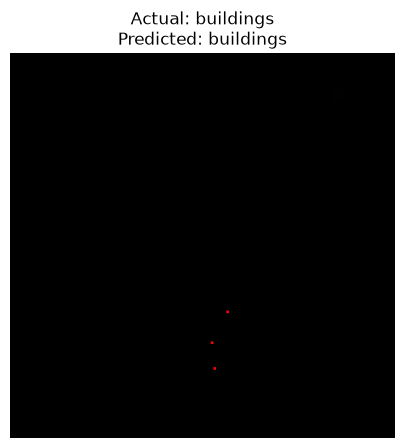

In [31]:
image_index = 0

plt.figure(figsize=(5, 5))
plt.imshow(images[image_index].numpy().astype("uint8"))

actual_class = class_names[labels[image_index]]
predicted_class = class_names[predicted_classes[image_index]]

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}"
)

plt.axis("off")
plt.show()

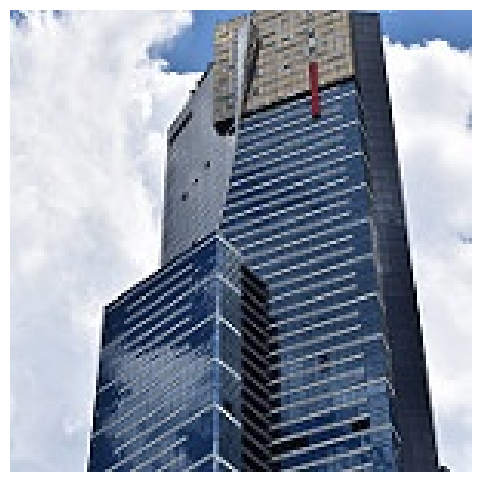

In [32]:
import os
from PIL import Image

test_image_path = os.path.join(test_dir, "buildings", os.listdir(os.path.join(test_dir, "buildings"))[0])

original_image = Image.open(test_image_path)

plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.axis("off")
plt.show()

In [33]:
img = original_image.resize((299, 299))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)

processed_img = preprocess_input(img_array)

prediction = model.predict(processed_img)

predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

print("Predicted:", class_names[predicted_class])
print("Confidence:", f"{confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted: buildings
Confidence: 98.83%


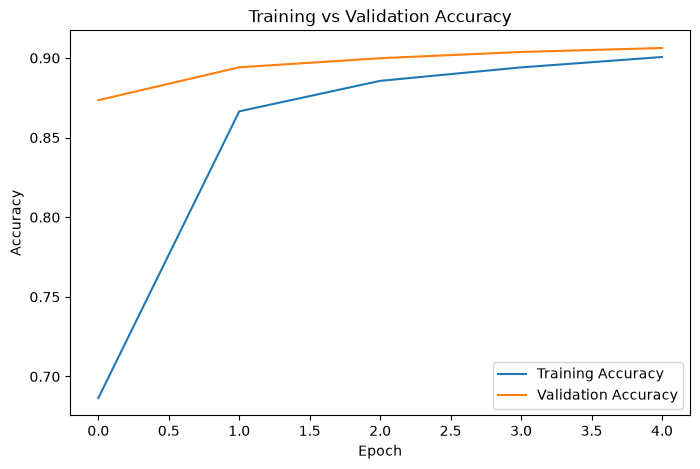

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

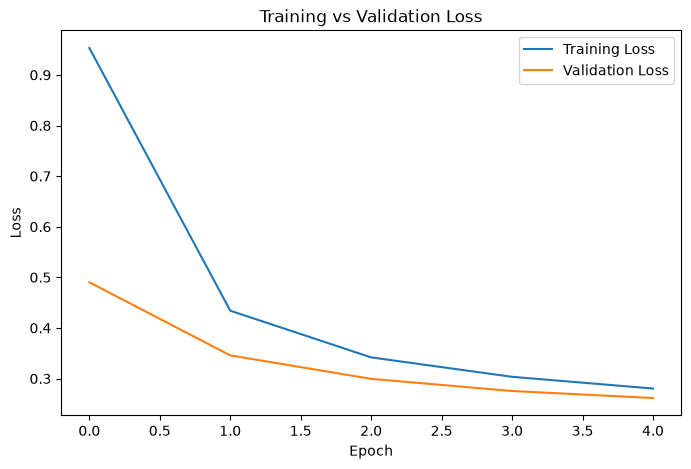

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [36]:
model.save("inceptionv3_scene_classifier.keras")

In [37]:
from tensorflow import keras

loaded_model = keras.models.load_model(
    "inceptionv3_scene_classifier.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [38]:
img = original_image.resize((299, 299))

img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)

processed_img = preprocess_input(img_array)

prediction = loaded_model.predict(processed_img)

predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class]

print("Predicted:", class_names[predicted_class])
print("Confidence:", f"{confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: buildings
Confidence: 98.83%
